In [1]:
import torch
from torch import nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
from datetime import datetime

In [9]:
import torch.nn.functional as F

class Res3DBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=(1, 1, 1), downsample=False):
        super(Res3DBlock, self).__init__()
        
        # 第一卷积层 (3x3x1)，用于空间特征提取
        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=(3, 3, 1), stride=(1, 1, 1), padding=(1, 1, 0))
        self.bn1 = nn.BatchNorm3d(out_channels)
        # 第二卷积层 (3x3x1)，与第一卷积层相同
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=(3, 3, 1), stride=(1, 1, 1), padding=(1, 1, 0))
        self.bn2 = nn.BatchNorm3d(out_channels)
        self.relu = nn.ReLU(inplace=False)
        # 残差分支中卷积层
        self.convres = nn.Conv3d(in_channels, out_channels, kernel_size=(1, 1, 1), stride=(1, 1, 1))
        self.bnres = nn.BatchNorm3d(out_channels)
        
        # 下采样
        # self.downsample = downsample
        # if downsample:
        #     # 下采样卷积层 (2x2x2)
        #     self.downsample_layer = nn.Conv3d(in_channels, out_channels, kernel_size=(2, 2, 2), stride=(2, 2, 1))
        #     self.bn_downsample = nn.BatchNorm3d(out_channels)
        self.downsample_layer = nn.Conv3d(out_channels, out_channels, kernel_size=(2, 2, 2), stride=(2, 2, 1))
        self.bn_downsample = nn.BatchNorm3d(out_channels)
        return
    
    def forward(self, x):
        identity = x
        
        # 顺序分支
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        # 残差分支
        identity = self.convres(identity)
        identity = self.bnres(identity)
        identity = self.relu(identity)
        
        # # 如果需要下采样，处理残差连接部分
        # print('self.downsample',self.downsample)
        # if self.downsample:
        #     identity = self.downsample_layer(identity)
        #     print('identity.shape', identity.shape)
        #     identity = self.bn_downsample(identity)
        
        # 残差连接
        # print(out.shape, identity.shape)
        out = torch.add(out,identity)
        # out += identity
        out = self.relu(out)
        out = self.downsample_layer(out)
        out = self.bn_downsample(out)
        out = self.relu(out)
       
        return out


class Res3D(nn.Module):
    def __init__(self,in_channels,out_featrues):
        super(Res3D, self).__init__()
        # 块1：输入通道 32，输出通道 32
        # self.block1 = Res3DBlock(in_channels=3, out_channels=32)
        self.block1 = Res3DBlock(in_channels=in_channels, out_channels=32, downsample=True)
        # 块2：输入通道 32，输出通道 64
        self.block2 = Res3DBlock(in_channels=32, out_channels=64, downsample=True)
        # 块3：输入通道 64，输出通道 64
        self.block3 = Res3DBlock(in_channels=64, out_channels=64)
        # 块4：输入通道 64，输出通道 128
        # self.block4 = Res3DBlock(in_channels=64, out_channels=128, downsample=True)
        # 块5：输入通道 128，输出通道 128
        # self.block5 = Res3DBlock(in_channels=128, out_channels=128)
        # 全连接层
        self.fc = nn.Linear(64, out_featrues)  # 假设全连接层输入 1782 维度
    
    def forward(self, x):
        # 第一个残差块
        x = self.block1(x)
        # 第二个残差块
        x = self.block2(x)
        # 第三个残差块
        x = self.block3(x)
        # 第四个残差块
        # x = self.block4(x)
        # 第五个残差块
        # x = self.block5(x)
        # 平均池化
        x = F.adaptive_avg_pool3d(x, (1, 1, 1))
        x = torch.flatten(x, 1)
        # 全连接层
        x = self.fc(x)
        
        return x



In [10]:
# 测试网络
from torchsummary import summary
batch_size = 4
model = Res3D(3,233)
summary(model,input_size=(3,200,200,8),batch_size=batch_size)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv3d-1       [4, 32, 200, 200, 8]             896
       BatchNorm3d-2       [4, 32, 200, 200, 8]              64
              ReLU-3       [4, 32, 200, 200, 8]               0
            Conv3d-4       [4, 32, 200, 200, 8]           9,248
       BatchNorm3d-5       [4, 32, 200, 200, 8]              64
              ReLU-6       [4, 32, 200, 200, 8]               0
            Conv3d-7       [4, 32, 200, 200, 8]             128
       BatchNorm3d-8       [4, 32, 200, 200, 8]              64
              ReLU-9       [4, 32, 200, 200, 8]               0
             ReLU-10       [4, 32, 200, 200, 8]               0
           Conv3d-11       [4, 32, 100, 100, 7]           8,224
      BatchNorm3d-12       [4, 32, 100, 100, 7]              64
             ReLU-13       [4, 32, 100, 100, 7]               0
       Res3DBlock-14       [4, 32, 100,

In [ ]:
input_tensor = torch.randn(32, 3, 200, 200, 8)  # (batch_size, channels, height, width, depth)
output = model(input_tensor)
print(output.shape)

Model Train

In [5]:
# hyper
batch_size = 32
num_epochs = 40
k_folds = 5
learning_rate = 1e-3
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

In [6]:
from torch.optim.swa_utils import AveragedModel, SWALR
from torch.optim.lr_scheduler import CosineAnnealingLR
# 封装 SWA 模型
swa_model = AveragedModel(model)
# 使用余弦退火学习率调度器
scheduler = CosineAnnealingLR(optimizer, T_max=100)
# 使用 SWA 的学习率调度器
swa_scheduler = SWALR(optimizer, swa_lr=0.05)

In [7]:
# 读取训练数据
import numpy as np
samples = np.load('../taicangNet/samples.npy')
samples = torch.tensor(samples)
samples = samples.permute(4, 2, 0, 1,3)
labels = np.load('../taicangNet/labels.npy')
labels = torch.tensor(labels)
labels = labels.permute(1,0)
samples.shape

torch.Size([233, 3, 200, 200, 8])

In [8]:
# 设置训练集和测试集
num_train = 210
num_test = 23
# 生成随机索引
indices = torch.randperm(233)
train_indices = indices[:num_train]  # 前 210 个作为训练集
test_indices = indices[num_train:num_train + num_test]  # 接下来的 23 个作为测试集
# 根据索引划分训练集和测试集
train_set = samples[train_indices]
test_set = samples[test_indices]
train_label = labels[train_indices]
test_label = labels[test_indices]

In [9]:
labels.shape

torch.Size([233, 256])

In [35]:
# 生成随机训练数据和标签
# # 输入大小 (32, 3, 48, 48, 18)，输出大小 (6, 297)
# input_size = (170, 3, 48, 48, 18)  # 总共有 4170 个样本
# output_size = (170, 1782)  # 每个样本的标签是 (6, 297)

# 随机生成正的训练数据和标签
X = train_set  # 输入特征，取绝对值
y = train_label  # 标签，取绝对值

train_losses = []  # 存储每个epoch的训练损失
val_losses = []  # 存储每个epoch的验证损失

In [ ]:
# 启用异常检测功能
torch.autograd.set_detect_anomaly(True)
kf = KFold(n_splits=k_folds, shuffle=True)

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f'Fold {fold+1}/{k_folds}')
    
    # 训练集和验证集划分
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # 使用 TensorDataset 和 DataLoader 分批加载数据
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_train, y_train)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # 训练轮次
    for epoch in range(num_epochs):
        if epoch < 30:
            model.train()
            running_loss = 0.0
            
            for inputs, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

        else:
            model.train()
            running_loss = 0.0
            
            for inputs, labels in train_loader:
                # 使用 SWA 模型，开始进行参数的平均
                optimizer.zero_grad()
                output = model(inputs)
                loss = criterion(output, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
                # 更新 SWA 模型的参数
                swa_model.update_parameters(model)
                swa_scheduler.step()
    
        
        # 打印训练损失
        if (epoch + 1) % 1 == 0:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for val_inputs, val_labels in val_loader:
                    val_outputs = model(val_inputs)
                    loss = criterion(val_outputs, val_labels)
                    val_loss += loss.item()
            train_losses.append(running_loss/len(train_loader))
            val_losses.append(val_loss/len(train_loader))
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(train_loader):.4f}')
    
    # 最后更新 SWA BN 统计
    torch.optim.swa_utils.update_bn(train_loader, swa_model)

Fold 1/5


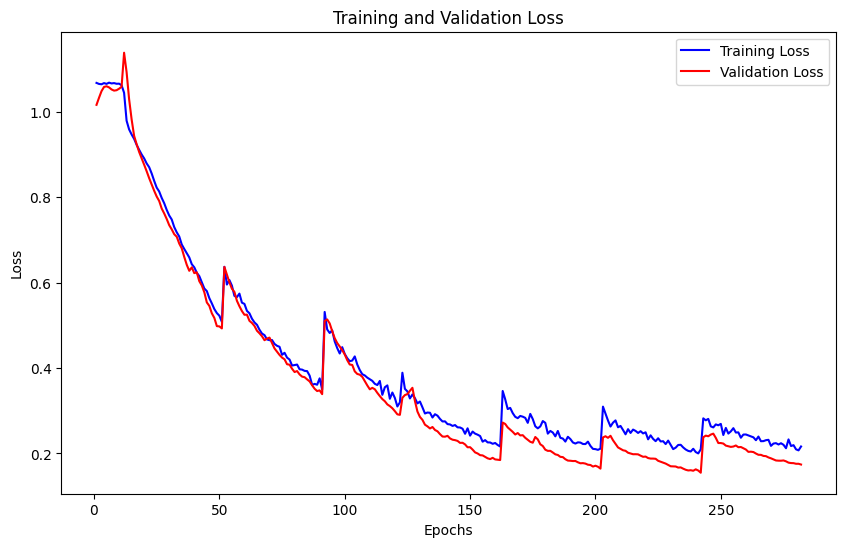

In [63]:
# 画出训练和验证的学习曲线
import matplotlib.pyplot as plt
def plot_learning_curve(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, 'b', label='Training Loss')
    plt.plot(epochs, val_losses, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# 示例使用函数（你可以在训练结束后调用该函数）
plot_learning_curve(train_losses, val_losses)

Fold 0
Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9


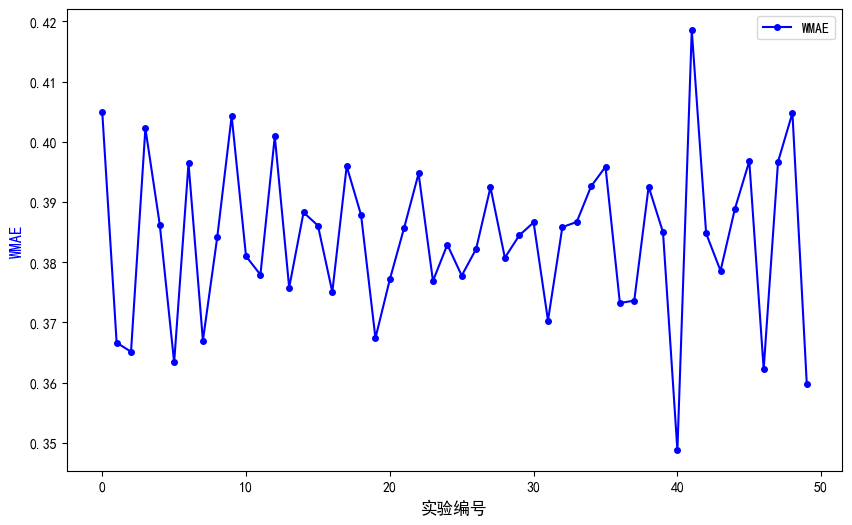

In [76]:
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False 
def calculate_errors(y_true, y_pred, weights):
    WMAE = np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)
    WRMSE = np.sqrt(np.sum(weights * (y_true - y_pred) ** 2) / np.sum(weights))
    WMAPE = np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights * y_true)
    WMSPE = np.sqrt(np.sum(weights * ((y_true - y_pred) / y_true) ** 2) / np.sum(weights))
    return WMAE, WRMSE, WMAPE, WMSPE

# 数据生成示例
input_size = (170, 3, 48, 48, 18)
output_size = (170, 1782)
weights = torch.abs(y)+1  # 权重

# 初始化 KFold
kf = KFold(n_splits=5, shuffle=True)

# 存储20轮交叉验证的结果
WMAE_list = []
WMAPE_list = []

# 执行5折交叉验证，进行20轮
for iteration in range(10):
    print(f'Fold {iteration}')
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        weights_test = weights[test_idx]

        y_pred = model(X_test)

        # 计算 WMAE 和 WMAPE
        WMAE, _, WMAPE, _ = calculate_errors(y_test.numpy(), y_pred.detach().numpy(), weights_test.numpy())
        
        WMAE_list.append(WMAE)
        WMAPE_list.append(WMAPE * 100)  # 将 WMAPE 转换为百分比

def plt_error(WMAE_list):
    # 绘制误差分布图
    plt.figure(figsize=(10, 6))

    # 绘制 WMAE
    plt.plot(WMAE_list, 'bo-', label='WMAE', markersize=4)
    plt.ylabel('WMAE', fontsize=12, color='blue')
    plt.xlabel('实验编号', fontsize=12)
    plt.legend(loc='upper right')
    plt.show()

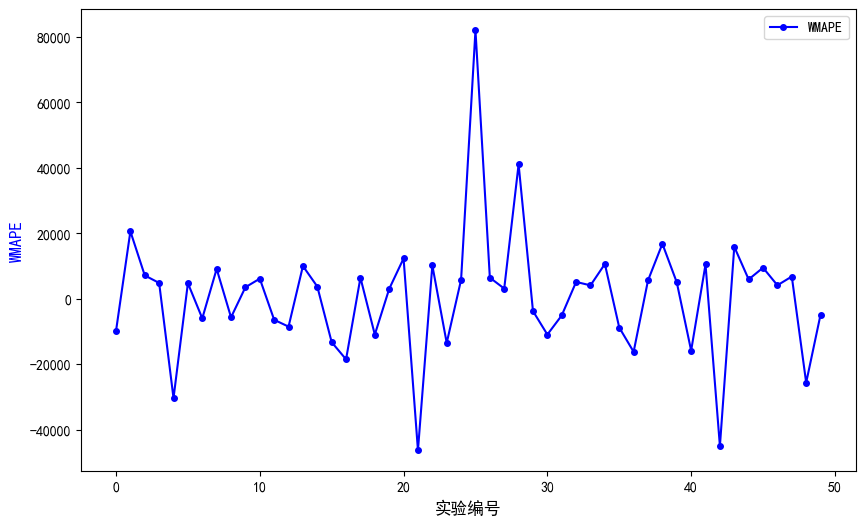

In [80]:
# 绘制误差分布图
plt.figure(figsize=(10, 6))

# 绘制 WMAPE
plt.plot(WMAPE_list, 'bo-', label='WMAPE', markersize=4)
plt.ylabel('WMAPE', fontsize=12, color='b')
plt.xlabel('实验编号', fontsize=12)
plt.legend(loc='upper right')
plt.show()